In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, norm

In [2]:
##Q1

##Define a Monte Carlo Intersection Volume calculator function
    # Input: sphere and torus parameters, sample size N, seed for random generator, center values, which size of box to use
    # Function creates a sample and checks what points are on the intersect
    # Output is the volume of the intersect

def mc_intersection_volume(k, R, r, x_c, y_c , z_c, N, small = False, seed = None, return_points=False):
    rng = np.random.default_rng(seed) # set random generator for reproducability 
    # define box shape
    if small:
        H = min(k, abs(z_c)+r)
        L = min(k, abs(x_c)+R+r, abs(y_c)+R+r)     # MC Box contains only intersection
        V_box = ((2*L)**2) *2*H
    else: 
        H = max(k, abs(z_c)+r)
        L = max(k, abs(x_c)+R+r, abs(y_c)+R+r)     # MC Box contains both shapes completely
        V_box = ((2*L)**2) *2*H
    #generate sample 
    x = rng.uniform(-L, L, size=N)
    y = rng.uniform(-L, L, size=N)
    z = rng.uniform(-H, H, size=N)
    sample = np.column_stack([x, y, z])
    # check if points are in the intersection
    in_sphere = x**2 + y**2 + z**2 <= k**2
    in_torus = (np.sqrt((x-x_c)**2+(y-y_c)**2) - R)**2 + (z-z_c)**2 <= r**2
    #  calculate ratio of points at intersection
    in_intersect = in_sphere & in_torus
    ratio = np.mean(in_intersect) # (number of True) / N -> True corresponds to point in intersect
    vol = V_box * ratio
    if return_points:
        return vol, sample, in_intersect, in_sphere, in_torus, L, H
    else:
        return vol

In [3]:
def run_mc_simulations(k, R, r, x_c, y_c, z_c, N, n_simulations=30):
    results = {}
    stats = {}

    for box_size in ["min", "max"]:
        key = f"{(R, r)}, {box_size}"
        vols = []
        for sim in range(n_simulations):
            vol = mc_intersection_volume(
                k, R, r, x_c, y_c, z_c, N,
                small=(box_size == "min"),
                seed=sim
                )
            vols.append(vol)

        vols = np.array(vols)
        results[key] = vols
        stats[key] = {
            "mean": np.mean(vols),
            "std": np.std(vols),
            }

    return results, stats


In [4]:
# Ex 1
x1_c, y1_c, z1_c = 0.0, 0.0, 0.0
N = 100000
# Case A
k = 1
R_a = 0.75
r_a = 0.4

# Case B
R_b = 0.5
r_b = 0.5

In [5]:
results_mc1_A, results_mc1_stats_A = run_mc_simulations(k, R_a, r_a, x1_c, y1_c, z1_c, N, n_simulations=30)
results_mc1_B, results_mc1_stats_B = run_mc_simulations(k, R_b, r_b, x1_c, y1_c, z1_c, N, n_simulations=30)

In [6]:
def plot_distribution(results, results_stats):
        cols = len(results.keys())
        fig, axs = plt.subplots(ncols=cols, nrows=1, figsize=(10, 5))
        for i, (key, vals) in enumerate(results.items()):
                mu = results_stats[key]["mean"]
                sigma = results_stats[key]["std"]
                ax = axs[i]
                ax.hist(vals, bins=15, density = True, alpha = 0.8)
                ax.axvline(mu, color="red", linestyle="--", linewidth=2, label=f"$\\mu$={mu:.3f}, $\\sigma$ ={sigma:.3f}")

                # estimate pdf based on data
                kde = gaussian_kde(vals)
                x_vals = np.linspace(min(vals), max(vals), 200)
                ax.plot(x_vals, kde(x_vals), color="darkblue", lw=2, label="Estimated PDF")

                # actual gaussian pdf
                norm_curve = norm.pdf(x_vals, mu, sigma)
                ax.plot(x_vals, norm_curve, color="green", ls = "--", alpha = 0.8, label="Normal PDF")

                ax.set_title(f"{key}")
                ax.set_xlabel("Estimated Volume")
                ax.set_ylabel("Density")
                ax.legend()

        plt.suptitle("Monte Carlo Volume Distribution", fontsize=14, y=1)
        plt.tight_layout()
        plt.show()

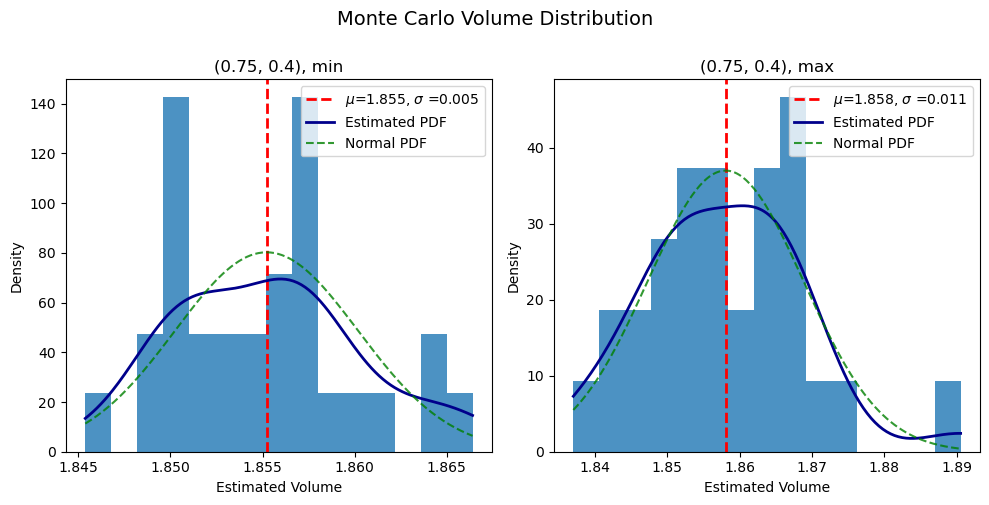

In [7]:
plot_distribution(results_mc1_A, results_mc1_stats_A)

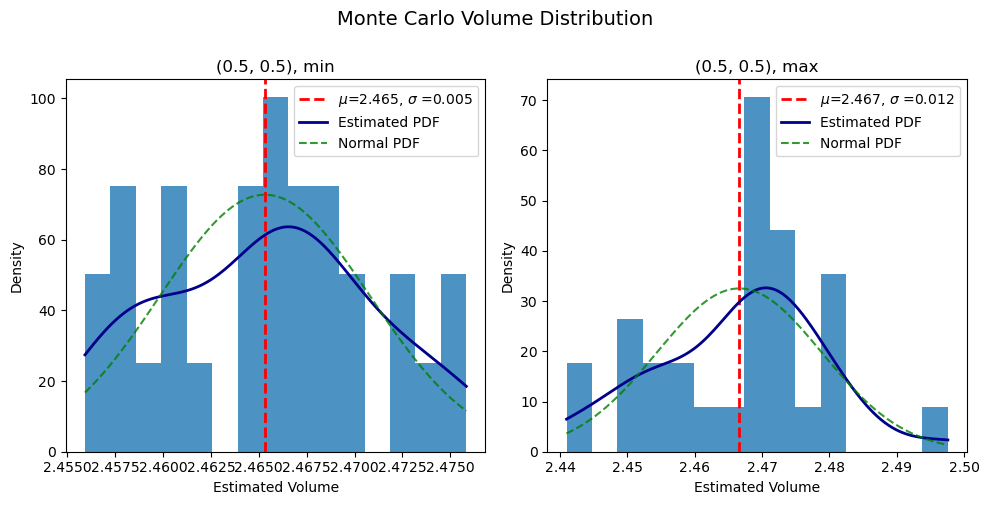

In [168]:
plot_distribution(results_mc1_B, results_mc1_stats_B)

In [7]:
def plot_cross_section_with_box(k, R, r, x_c, y_c, z_c, N=100000, seed=0, small=False, sequence = 'MC', m=3.8, x0=[0,0,0],y0=[0,0,0],z0=[0,0,0]):
    if sequence == 'MC':
        vol, sample, in_intersect, in_sphere, in_torus, L, H = mc_intersection_volume(
        k, R, r, x_c, y_c, z_c, N, small=small, seed=seed, return_points=True)
    if sequence == 'DET':
        vol, sample, in_intersect, L, H = det_intersection_volume(k, R, r, N, m, x0, y0, z0, return_points=True)

    # select slice near z=0
    mask = np.abs(sample[:, 2]) < 0.05
    mask = mask.ravel()
    in_intersect = in_intersect.ravel()
    plt.figure(figsize=(8, 8))
    plt.scatter(sample[mask, 0], sample[mask, 1], c="lightgray", s=1, label="Sample")
    plt.scatter(sample[mask & in_intersect, 0], sample[mask & in_intersect, 1], c="red", s=5, label="Intersection")

    # draw cross-section circles
    theta = np.linspace(0, 2 * np.pi, 400)
    x_sphere = k * np.cos(theta)
    y_sphere = k * np.sin(theta)
    plt.plot(x_sphere, y_sphere, "b--", lw=2, label="Sphere circle")

    x_torus_outer = (R + r) * np.cos(theta)
    y_torus_outer = (R + r) * np.sin(theta)
    x_torus_inner = (R - r) * np.cos(theta)
    y_torus_inner = (R - r) * np.sin(theta)
    plt.plot(x_torus_outer, y_torus_outer, color="orange", lw=2, label="Torus outer")
    plt.plot(x_torus_inner, y_torus_inner, color="orange", lw=2, linestyle="--", label="Torus inner")

    # draw box
    box_x = [-L, L, L, -L, -L]
    box_y = [-L, -L, L, L, -L]
    plt.plot(box_x, box_y, "k-", lw=2, label=f"Bounding Box (L={L:.2f}, H={H:.2f})")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Sphere vs Torus Cross-Section (z≈0)\nBox={'small' if small else 'large'}, Sphere (k={k}), Torus (R={R}, r={r})")
    plt.figlegend(loc='center right', bbox_to_anchor=(1.2, 0.8))
    plt.show()

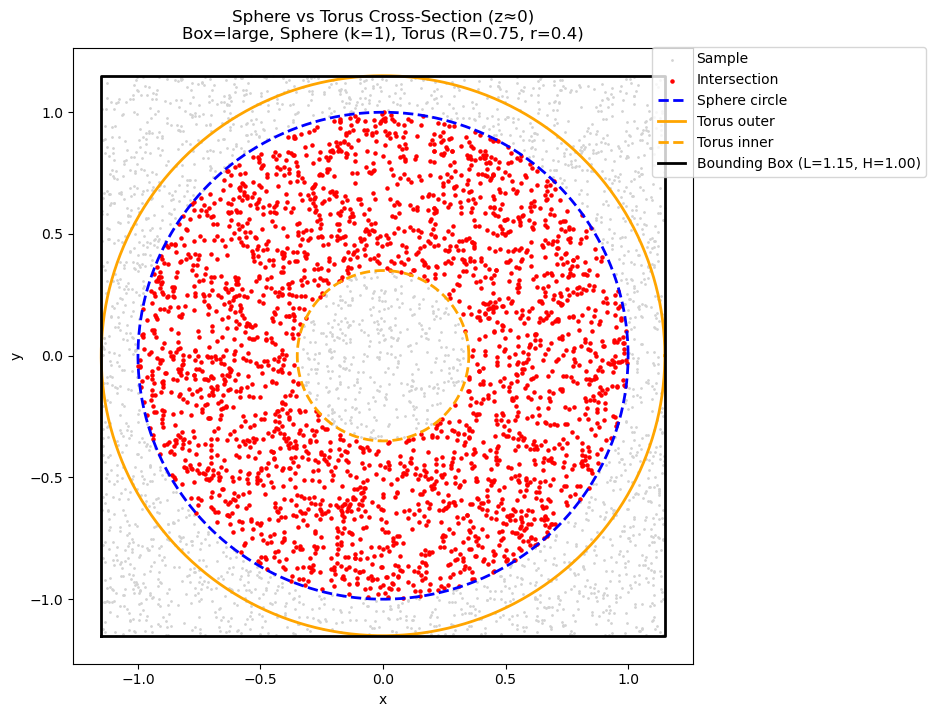

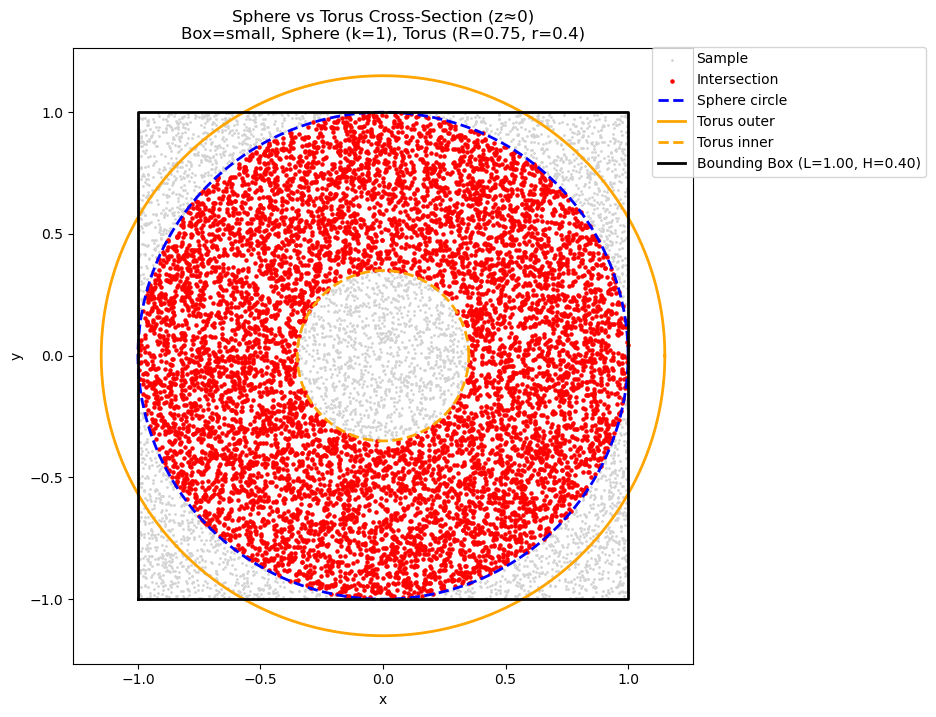

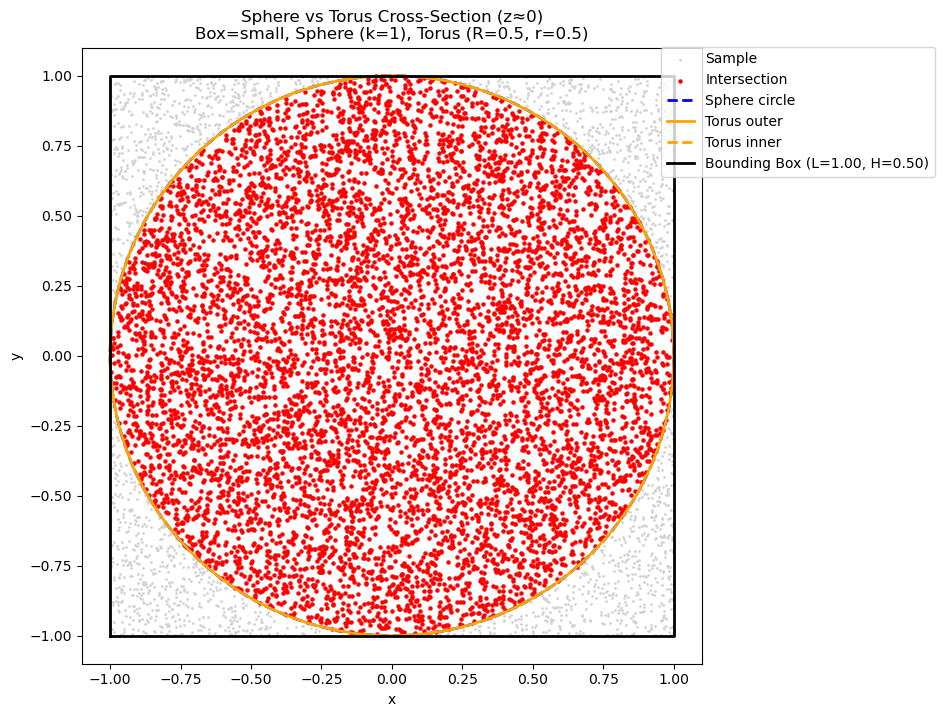

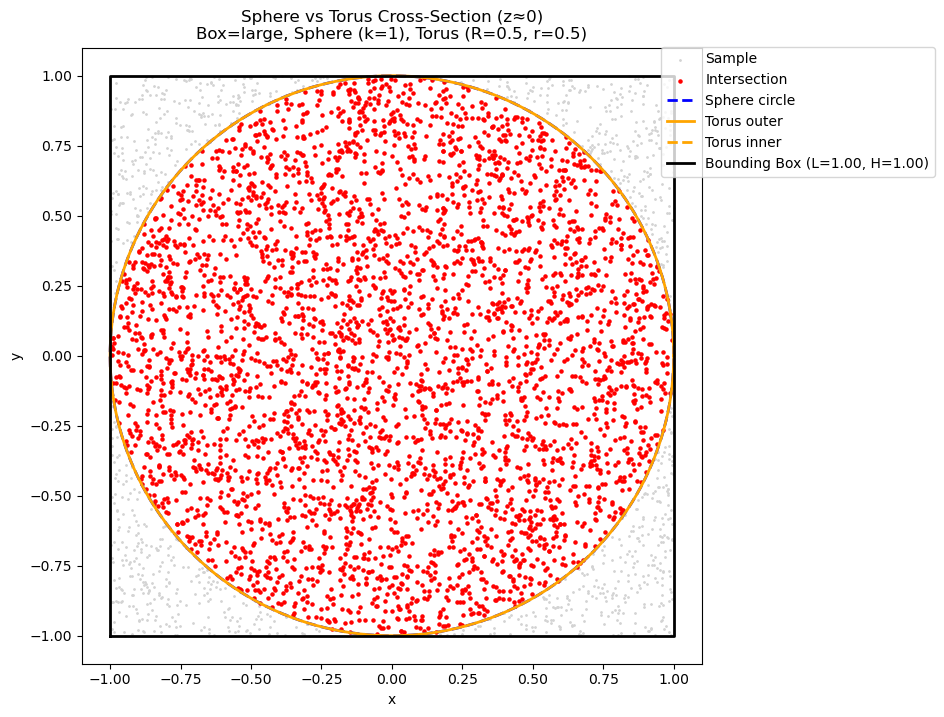

In [116]:
plot_cross_section_with_box(k, R_a, r_a, x1_c, y1_c, z1_c, small=False, sequence="MC")
plot_cross_section_with_box(k, R_a, r_a, x1_c, y1_c, z1_c, small=True, sequence="MC")
plot_cross_section_with_box(k, R_b, r_b, x1_c, y1_c, z1_c, small=True, sequence="MC")
plot_cross_section_with_box(k, R_b, r_b, x1_c, y1_c, z1_c, small=False, sequence="MC")

In [16]:
###Q2

## The sampling sequence is now determined deterministically
# We  reuse the function from Q1 but add inputs m and x0 

def det_intersection_volume(k, R, r, N, m, x0, y0, z0, return_points=False):
    H = min(k, r)
    L = min(k, R+r, R+r)   
    V_box = ((2*L)**2) *2*H

    # generate sample deterministically
    X = np.empty((N, 1))
    Y = np.empty((N, 1))
    Z = np.empty((N, 1))
    X[0], Y[0], Z[0] = x0, y0, z0 #set starting condition
    for i in range(1,N):
        X[i] = m * X[i-1] * (1 - X[i-1])
        Y[i] = m * Y[i-1] * (1 - Y[i-1])
        Z[i] = m * Z[i-1] * (1 - Z[i-1])
    x, y, z = (2*X - 1)*L, (2*Y-1)*L, (2*Z-1)*H # logistic sequence (btw 0 and 1) scaled to box size
    sample = np.column_stack([x, y, z])
    print(sample)

    # check if points are in the intersection
    in_sphere = x**2 + y**2 + z**2 <= k**2
    in_torus = (np.sqrt(x**2+y**2) - R)**2 + z**2 <= r**2
    in_intersect = in_sphere & in_torus
    ratio = np.mean(in_intersect) # (number of True) / N -> True corresponds to point in intersect
    vol = V_box * ratio
    if return_points:
        return vol, sample, in_intersect, L, H
    else: 
        return vol

In [ ]:
m = 3.8
x0 = np.random.rand(1,3) #x0,y0,z0 for logistic map should be between 0 and 1
y0 = np.random.rand(1,3)
z0 = np.random.rand(1,3)

In [21]:
vol0  = det_intersection_volume(k, R_a, r_a, N, m, x0[:,0],y0[:,0],z0[:,0])
vol1  = det_intersection_volume(k, R_a, r_a, N, m, x0[:,1],y0[:,1],z0[:,1])
vol2  = det_intersection_volume(k, R_a, r_a, N, m, x0[:,2],y0[:,2],z0[:,2])

vol0_arr = np.full(shape=30, fill_value=vol0)
vol1_arr = np.full(shape=30, fill_value=vol1)
vol2_arr = np.full(shape=30, fill_value=vol2)

/var/folders/z1/7kbjhk_n18x0w1rlzpp72dl40000gn/T/ipykernel_31108/113724929.py:18: RuntimeWarning: overflow encountered in multiply
  Y[i] = m * Y[i-1] * (1 - Y[i-1])
/var/folders/z1/7kbjhk_n18x0w1rlzpp72dl40000gn/T/ipykernel_31108/113724929.py:17: RuntimeWarning: overflow encountered in multiply
  X[i] = m * X[i-1] * (1 - X[i-1])
/var/folders/z1/7kbjhk_n18x0w1rlzpp72dl40000gn/T/ipykernel_31108/113724929.py:19: RuntimeWarning: overflow encountered in multiply
  Z[i] = m * Z[i-1] * (1 - Z[i-1])


[[   1.96969066    2.22368021    0.68209684]
 [  -6.47139443   -8.495032     -1.84996644]
 [ -78.66999719 -136.21458045  -15.89628516]
 ...
 [         -inf          -inf          -inf]
 [         -inf          -inf          -inf]
 [         -inf          -inf          -inf]]


/var/folders/z1/7kbjhk_n18x0w1rlzpp72dl40000gn/T/ipykernel_31108/113724929.py:25: RuntimeWarning: overflow encountered in square
  in_sphere = x**2 + y**2 + z**2 <= k**2
/var/folders/z1/7kbjhk_n18x0w1rlzpp72dl40000gn/T/ipykernel_31108/113724929.py:26: RuntimeWarning: overflow encountered in square
  in_torus = (np.sqrt(x**2+y**2) - R)**2 + z**2 <= r**2


[[ 0.21087755  0.95645645  0.5716345 ]
 [ 0.81550825 -0.838137   -1.19213853]
 [-0.36360205 -0.43469989 -6.39067282]
 ...
 [-0.21728508 -0.45567608        -inf]
 [ 0.81029567  0.50548268        -inf]
 [-0.34750022  0.41452579        -inf]]
[[ 0.31261067  0.59761691  0.16999975]
 [ 0.71432168  0.22142265  0.2227254 ]
 [-0.06948538  0.80684682  0.12436863]
 ...
 [-0.61077261  0.45818509  0.26939699]
 [ 0.19121795  0.50112621  0.01527   ]
 [ 0.83052782  0.42285779  0.35889243]]


/var/folders/z1/7kbjhk_n18x0w1rlzpp72dl40000gn/T/ipykernel_31108/113724929.py:18: RuntimeWarning: overflow encountered in multiply
  Y[i] = m * Y[i-1] * (1 - Y[i-1])
/var/folders/z1/7kbjhk_n18x0w1rlzpp72dl40000gn/T/ipykernel_31108/113724929.py:17: RuntimeWarning: overflow encountered in multiply
  X[i] = m * X[i-1] * (1 - X[i-1])
/var/folders/z1/7kbjhk_n18x0w1rlzpp72dl40000gn/T/ipykernel_31108/113724929.py:19: RuntimeWarning: overflow encountered in multiply
  Z[i] = m * Z[i-1] * (1 - Z[i-1])


[[   1.96969066    2.22368021    0.68209684]
 [  -6.47139443   -8.495032     -1.84996644]
 [ -78.66999719 -136.21458045  -15.89628516]
 ...
 [         -inf          -inf          -inf]
 [         -inf          -inf          -inf]
 [         -inf          -inf          -inf]]


/var/folders/z1/7kbjhk_n18x0w1rlzpp72dl40000gn/T/ipykernel_31108/113724929.py:25: RuntimeWarning: overflow encountered in square
  in_sphere = x**2 + y**2 + z**2 <= k**2
/var/folders/z1/7kbjhk_n18x0w1rlzpp72dl40000gn/T/ipykernel_31108/113724929.py:26: RuntimeWarning: overflow encountered in square
  in_torus = (np.sqrt(x**2+y**2) - R)**2 + z**2 <= r**2


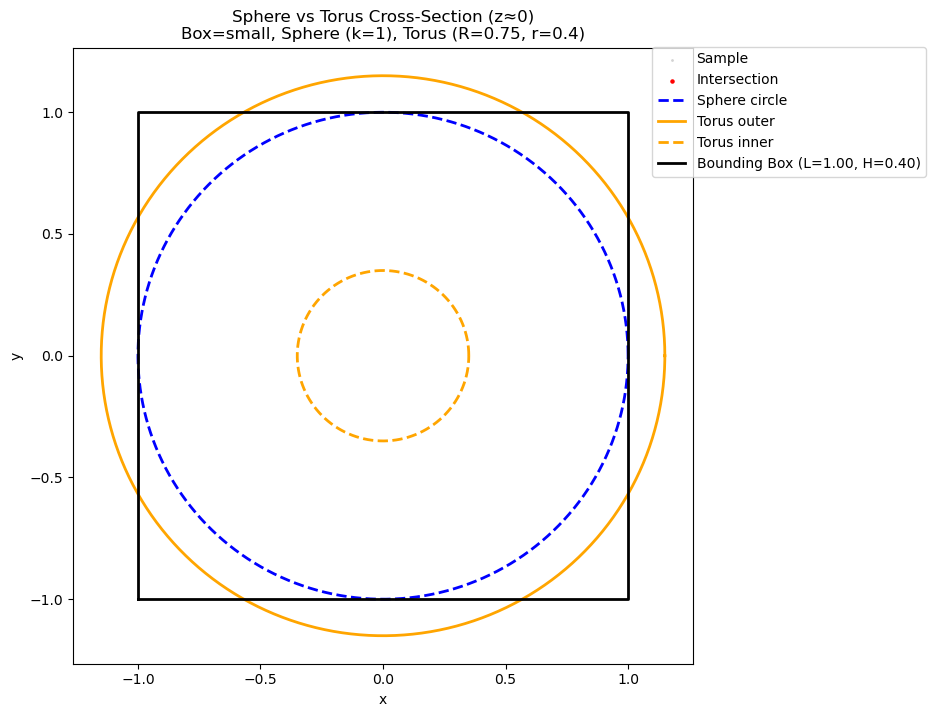

In [22]:
plot_cross_section_with_box(k, R_a, r_a, x1_c, y1_c, z1_c, N=100000, seed=0, small=True, sequence ='DET', m=3.8, x0=x0[:,0],y0=y0[:,0],z0=z0[:,0])

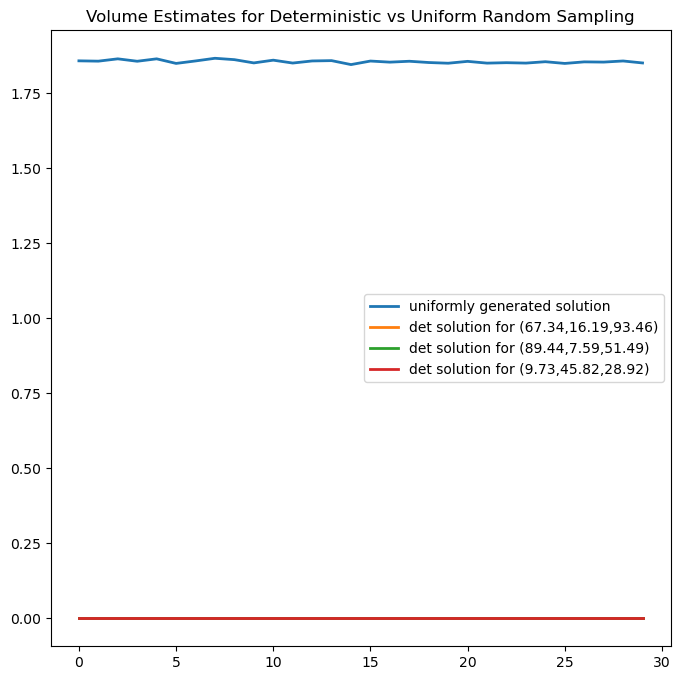

In [15]:
plt.figure(figsize=(8, 8))

simulations = np.arange(0,30)
mc = results_mc1_A[f"{R_a, r_a}, min"]
plt.plot(simulations, mc, lw = 2, label = "uniformly generated solution")
plt.plot(simulations, vol0_arr, lw = 2, label = f"det solution for ({np.round(x0[:,0].item(), 2)},{np.round(y0[:,0].item(), 2)},{np.round(z0[:,0].item(), 2)})")
plt.plot(simulations, vol1_arr, lw = 2, label = f"det solution for ({np.round(x0[:,1].item(), 2)},{np.round(y0[:,1].item(), 2)},{np.round(z0[:,1].item(), 2)})")
plt.plot(simulations, vol2_arr, lw = 2, label = f"det solution for ({np.round(x0[:,2].item(), 2)},{np.round(y0[:,2].item(), 2)},{np.round(z0[:,2].item(), 2)})")
plt.title("Volume Estimates for Deterministic vs Uniform Random Sampling")
plt.legend()

In [126]:
vol0_b = det_intersection_volume(k, R_b, r_b, N, m, x0[:,0],y0[:,0],z0[:,0])
vol1_b = det_intersection_volume(k, R_b, r_b, N, m, x0[:,1],y0[:,1],z0[:,1])
vol2_b = det_intersection_volume(k, R_b, r_b, N, m, x0[:,2],y0[:,2],z0[:,2])

vol0_b_arr = np.full(shape=30, fill_value=vol0_b)
vol1_b_arr = np.full(shape=30, fill_value=vol1_b)
vol2_b_arr = np.full(shape=30, fill_value=vol2_b)

[[ 0.4656352   0.12839046  0.44651992]
 [ 0.48804933  0.86868019 -0.30764415]
 [ 0.44743491 -0.53375002  0.09034928]
 ...
 [ 0.45918059 -0.59247622  0.32806084]
 [ 0.49939105  0.23304667  0.04102913]
 [ 0.42615629  0.79680958  0.44360312]]
[[-0.73105091  0.58407212  0.21787813]
 [-0.11542732  0.25183354  0.26961065]
 [ 0.87468541  0.77950175  0.17377837]
 ...
 [-0.58929843  0.74429338  0.38203976]
 [ 0.24018199 -0.152548   -0.10462662]
 [ 0.79039396  0.85578531  0.40840242]]
[[ 0.761597    0.30961042 -0.25987988]
 [-0.20205697  0.71786863  0.1933573 ]
 [ 0.82242867 -0.07913721  0.30792923]
 ...
 [ 0.86861082  0.29954567  0.31546532]
 [-0.53352105  0.72951755  0.0718302 ]
 [ 0.35917505 -0.11117212  0.43039361]]


[[ 0.4656352   0.12839046  0.44651992]
 [ 0.48804933  0.86868019 -0.30764415]
 [ 0.44743491 -0.53375002  0.09034928]
 ...
 [ 0.45918059 -0.59247622  0.32806084]
 [ 0.49939105  0.23304667  0.04102913]
 [ 0.42615629  0.79680958  0.44360312]]


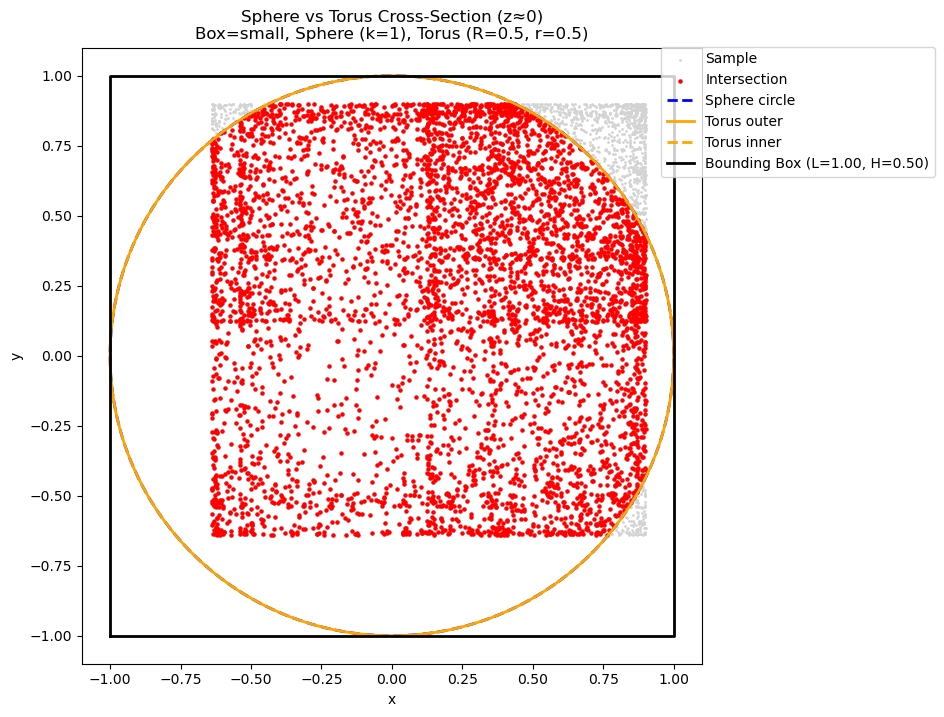

In [130]:
plot_cross_section_with_box(k, R_b, r_b, x1_c, y1_c, z1_c, N=100000, seed=0, small=True, sequence ='DET', m=3.8, x0=x0[:,0],y0=y0[:,0],z0=z0[:,0])

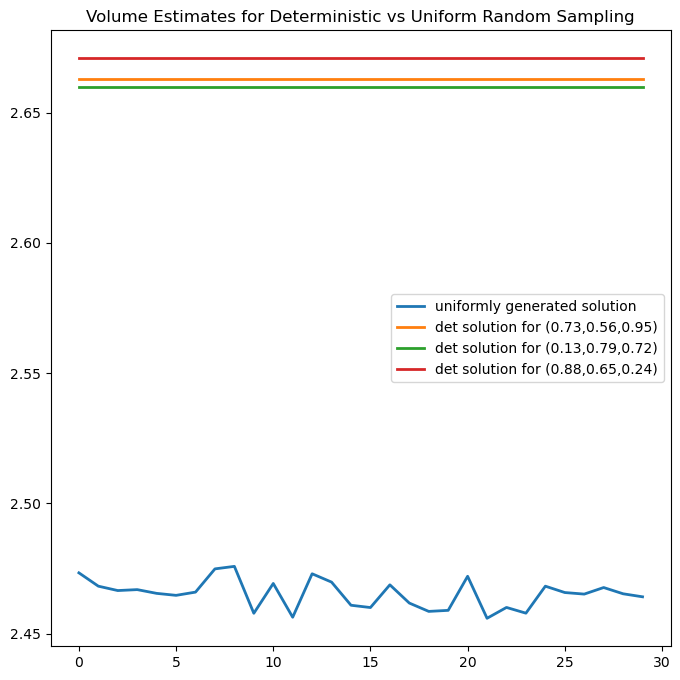

In [129]:
plt.figure(figsize=(8, 8))

simulations = np.arange(0,30)
mc_b = results_mc1_B[f"{R_b, r_b}, min"]
plt.plot(simulations, mc_b, lw = 2, label = "uniformly generated solution")
plt.plot(simulations, vol0_b_arr, lw = 2, label = f"det solution for ({np.round(x0[:,0].item(), 2)},{np.round(y0[:,0].item(), 2)},{np.round(z0[:,0].item(), 2)})")
plt.plot(simulations, vol1_b_arr, lw = 2, label = f"det solution for ({np.round(x0[:,1].item(), 2)},{np.round(y0[:,1].item(), 2)},{np.round(z0[:,1].item(), 2)})")
plt.plot(simulations, vol2_b_arr, lw = 2, label = f"det solution for ({np.round(x0[:,2].item(), 2)},{np.round(y0[:,2].item(), 2)},{np.round(z0[:,2].item(), 2)})")
plt.title("Volume Estimates for Deterministic vs Uniform Random Sampling")
plt.legend()

In [25]:
x3_c, y3_c, z3_c = 0, 0, 0.1
results_mc3, results_mc3_stats = run_mc_simulations(k, R_a, r_a, x3_c, y3_c, z3_c, N, n_simulations=30)

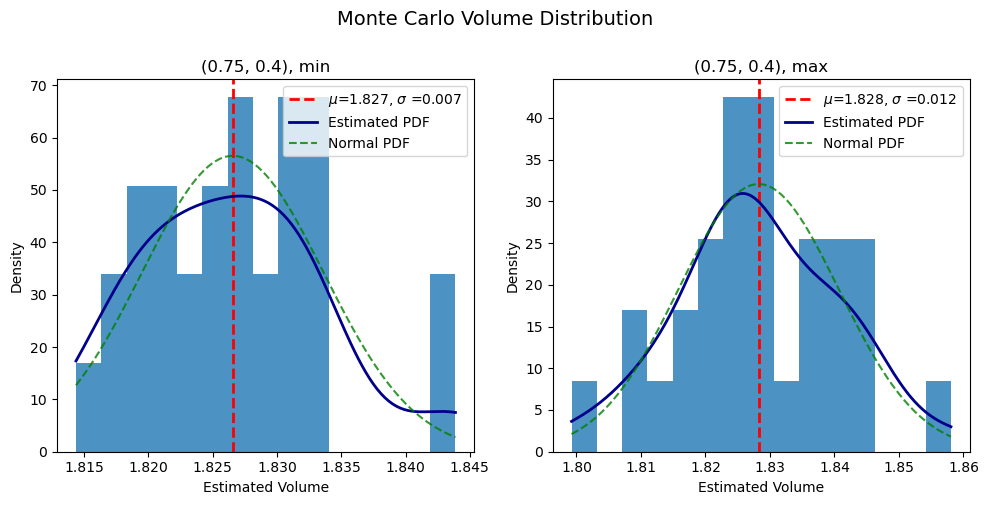

In [132]:
plot_distribution(results_mc3, results_mc3_stats)

In [ ]:
##Question 3b

def mc_offcenter_torus(k, R, r, x_c, y_c , z_c, N, p,  seed = None):
    rng = np.random.default_rng(seed)
    # Define box B
    L_B = max(k, abs(x_c)+R+r, abs(y_c)+R+r, abs(z_c)+r)
    V_B = (2*L_B)**3
    # Points that will be sampled from B with probability p
    from_B = rng.random(N) < p
    N_B = np.sum(from_B)
    # Points not sampled from B
    from_S = (from_B == 0)
    N_S = np.sum(from_S)

    sample = np.zeros((N, 3))

    # generate sample from B
    sample[from_B] = rng.uniform(-L_B,L_B, size = (N_B,3))
    # find intersection only over points from B
    xB, yB, zB = sample[from_B,0], sample[from_B,1], sample[from_B,2]
    in_sphere_B = xB**2 + yB**2 + zB**2 <= k**2
    in_torus_B = (np.sqrt((xB - x_c)**2+(yB -y_c)**2) - R)**2 + (zB-z_c)**2 <= r**2
    ratio_B = np.mean((in_sphere_B & in_torus_B))

    # points sampled from B that are in the intersection
    hits_B = sample[from_B][in_sphere_B & in_torus_B]
    # used to define box S
    min_corner = np.min(hits_B, axis=0)
    max_corner = np.max(hits_B, axis=0)
    L_S = max(max_corner - min_corner) / 2
    V_S = (2*L_S)**3

    # Second run only needs to run over box S, B already done
    sample[from_S] = rng.uniform([x_c - L_S, y_c - L_S, z_c - L_S],
            [x_c + L_S, y_c + L_S, z_c + L_S], size = (N_S,3))
    xS, yS, zS = sample[from_S,0], sample[from_S,1], sample[from_S,2]
    in_sphere_S = xS**2 + yS**2 + zS**2 <= k**2
    in_torus_S = (np.sqrt((xS-x_c)**2+(yS-y_c)**2) - R)**2 + (zS-z_c)**2 <= r**2
    ratio_S = np.mean((in_sphere_S & in_torus_S))

    # combine all the samples 
    sample = np.vstack((sample[from_B],sample[from_S]))

    # intersection indicator
    inside = np.concatenate((in_sphere_B & in_torus_B, in_sphere_S & in_torus_S))
    
    # compute f_mix for each sample 
    f_mix = np.full(N, p / V_B)  # initialize assuming from B
    # Add the (1 - p)/V_S part for samples inside S (because the sample inside S can be sampled from either B and S, we have to assign it a mixture distribution)
    mask_in_S = np.all(np.abs(sample) <= L_S, axis=1)
    f_mix[mask_in_S] += (1 - p) / V_S   

    # volume estimate as a weighted sum
    # vol = (ratio_B * V_B) * p + (ratio_S * V_S) * (1 - p) # original one
    vol = np.mean(inside/f_mix) # revised one(I think it's theoretically unbiased)
    ### Above calculation of the volume adds a slight bias towards the region S as this is currently contained in B and S
    return vol

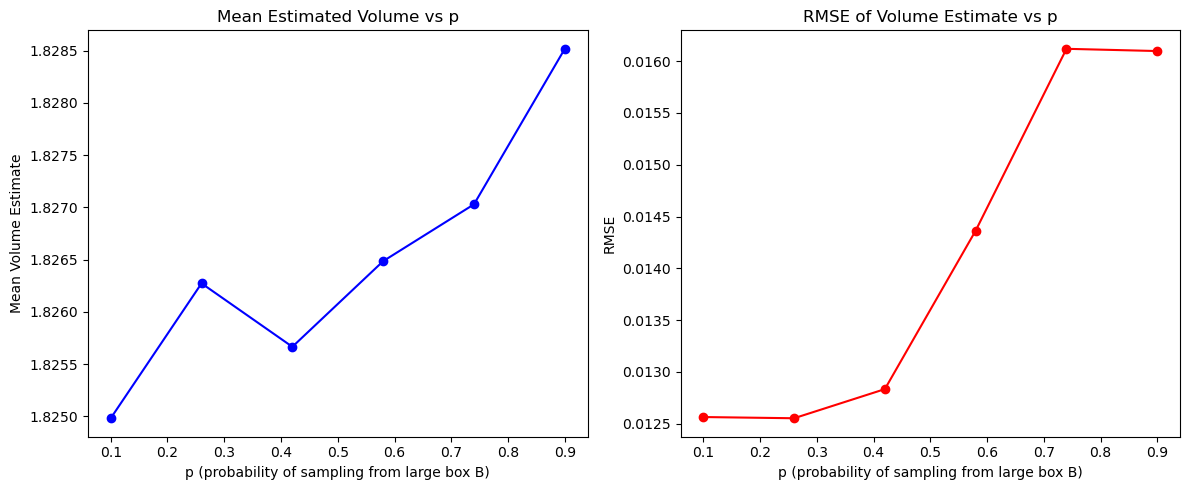

In [44]:
num_runs = 30
p_values = np.linspace(0.1, 0.9, 6) 

means, std = [], []
results_by_p = {}

# run simulations for different p values and get mean and std
for p in p_values:
    vols = [mc_offcenter_torus(k, R_a, r_a, x3_c, y3_c, z3_c, N, p, seed=i) for i in range(num_runs)]
    results_by_p[p] = vols
    means.append(np.mean(vols))
    std.append(np.std(vols))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(p_values, means, marker='o', color='blue')
ax[0].set_title("Mean Estimated Volume vs p")
ax[0].set_xlabel("p (probability of sampling from large box B)")
ax[0].set_ylabel("Mean Volume Estimate")

ax[1].plot(p_values, std, marker='o', color='red')
ax[1].set_title("RMSE of Volume Estimate vs p")
ax[1].set_xlabel("p (probability of sampling from large box B)")
ax[1].set_ylabel("RMSE")

plt.tight_layout()
plt.show()

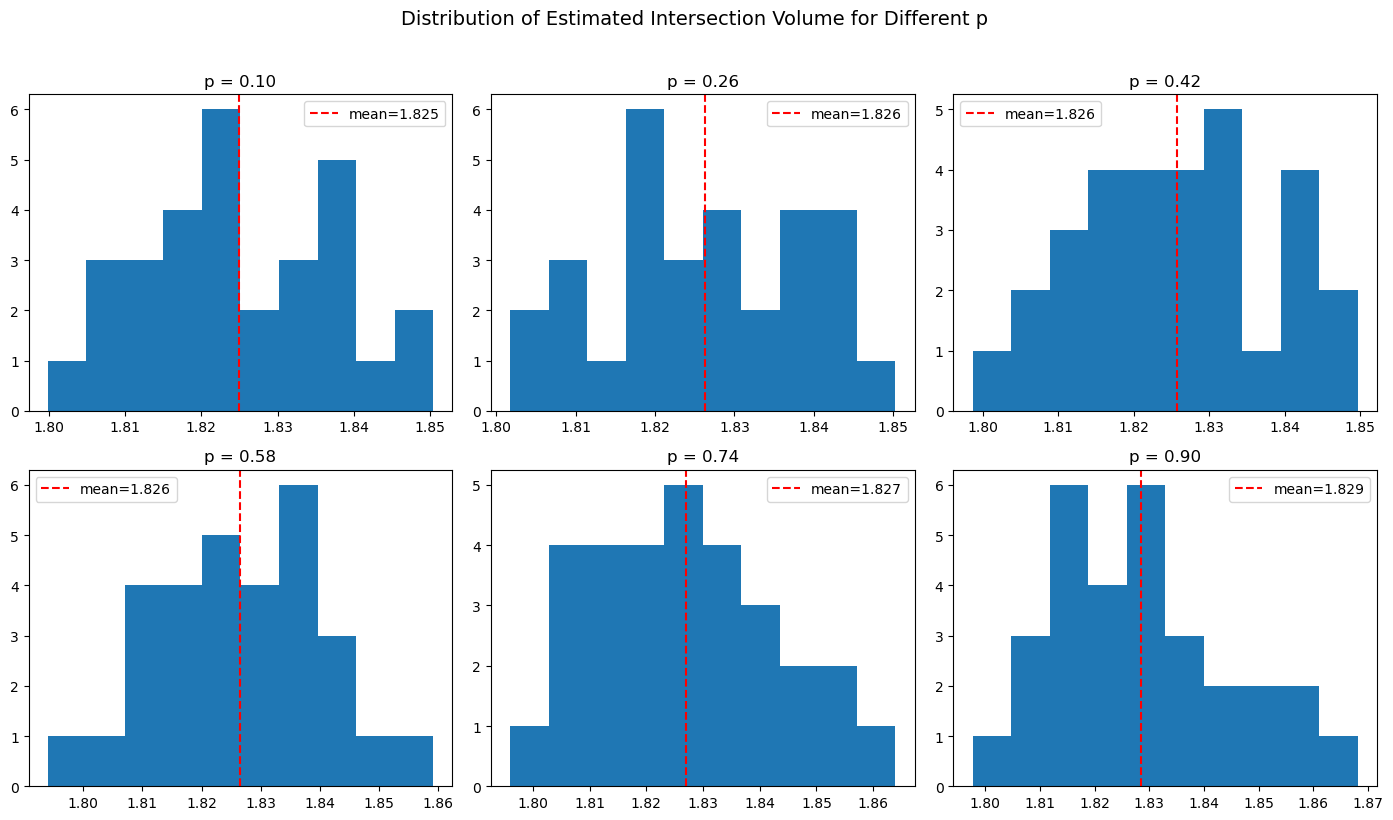

In [40]:
# plot distributions for different p
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, p in enumerate(p_values):
    vols = results_by_p[p]
    axes[i].hist(vols)
    axes[i].axvline(np.mean(vols), color="red", linestyle="--", label=f"mean={np.mean(vols):.3f}")
    axes[i].set_title(f"p = {p:.2f}")
    axes[i].legend()

plt.suptitle("Distribution of Estimated Intersection Volume for Different p", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
